# <a id='toc1_'></a>[Ableiten des epi Datensatzes für die ehemaligen GKR Länder aus den klinischen Daten](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Ableiten des epi Datensatzes für die ehemaligen GKR Länder aus den klinischen Daten](#toc1_)    
  - [Zusammenfassung ⚖️](#toc1_1_)    
  - [load data](#toc1_2_)    
  - [Datenstand 🕥](#toc1_3_)    
  - [Verteilungen in den Teildatensätzen](#toc1_4_)    
  - [Fallzahlen bei cut-off DJ 2020](#toc1_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

<br>

## <a id='toc1_1_'></a>[Zusammenfassung ⚖️](#toc0_)
- Ziel des Algorithmus ist es, die epi Daten für die ehemaligen GKR Länder zu erzeugen
- Für die DJ vor 2020 liegt ein Archiv der GKR Daten vor. Diese Daten wurden bis `epi2022` verwendet
- Für die DJ nach 2020 sollen epi Daten aus dem aktuellen Stand der klinischen Daten abgeleitet werden
- angewendete Regeln
  - GKR Archiv wird bis inkl. DJ 2019 verwendet
  - für die klinischen Daten (Stand Juli 2024, DJ 2022 flächendeckend enthalten): 
    - Filter nach kkr 11-16 ("nur GKR Länder")
    - über eine Auswahl von Spalten der Daten werden Duplikate ermittelt, also alle Fälle mit gleichen Ausprägungen dieser Spalten. (Details siehe Dokument: `Technische Prüfungen in klinischen und epi Daten` ). Von den Duplikaten wird jeweils nur ein zufälliger Fall übernommen (in den klinischen Daten selbst erfolgt keine Löschung von Daten)
    - beide Teildatensätze werden in das originale Lieferschema der GKR überführt, und in den workflow integriert 

<br>

## <a id='toc1_2_'></a>[load data](#toc0_)

In [1]:
import os
from pathlib import Path
import pandas as pd
from importlib import metadata as md
import duckdb as ddb
from connection_helper import sql
from pandas_plots import tbl, pls, hlp
import duckdb as ddb
import datetime as dt
import numpy as np

os.environ['THEME']='light'
hlp.show_package_version()

dir_files=Path(".local/files")
dir_db=Path("../../cancerdata-workflow/out/db/")

🐍 3.12.2 | 📦 pandas: 2.2.2 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.0.0 | 📦 pandas-plots: 0.11.4 | 📦 connection_helper: 0.7.2


In [2]:
con = ddb.connect()
con.execute("PRAGMA disable_progress_bar;")
con.execute(f"ATTACH DATABASE '{dir_db/'2024-06-25_data_clin_intern.db'}' AS clin;")
con.execute(f"ATTACH DATABASE '{dir_db/'data_epi_internal.db'}' AS epi;")
con.execute(f"ATTACH DATABASE '{dir_db/'data_gkr_intern.db'}' AS gkr;")

dim_dig, dim_dsich_clin, dim_dsich_epi, dim_grading, dim_grading_clin, dim_grading_epi, dim_icd10, dim_icd10_3d, dim_landkreis, dim_lieferregister, dim_op_intention, dim_tnm_t, dim_tnm_uicc, dim_tree=sql.unpack_files_to_duckdb(
    dir=Path("data/dim"),
    con=con,
    ext="csv",
    prefix="dim_",
    # debug=True,
    # verbose=True,
)

dim_lieferregister = dim_lieferregister.filter("kkr <> 'Total'")
Tumor = con.sql("select * from clin.Tumor")
Patient= con.sql("select * from clin.Patient")
# _duplicates = con.sql("select * from clin._duplicates")
# _plausis = con.sql("select * from clin._plausis")
# OPS = con.sql("select * from clin.OPS")
_meta = con.sql("select * from clin._meta")

Tumor4 = con.sql("select * from epi.Tumor4")
GKR = con.sql("select * from gkr.EKR")

In [3]:
cols_hash = "Diagnose_ICD10_Code, Morphologie_Code, Topographie_Code, Geburtsdatum, Diagnosedatum, Geschlecht, Verstorben, Inzidenzort, Seitenlokalisation, T_p, Grading, N_p, Diagnosesicherung, M_p"
db_clin = (Tumor.set_alias("t")
    .filter("cast(t.Lieferregister as int) > 10")
    .join(Patient.set_alias("p"), "oBDS_RKIPatientId")
    .project("""--sql
            t.oBDS_RKIPatientTumorId,
            t.oBDS_RKIPatientId, Diagnose_ICD10_Code, Morphologie_Code, Topographie_Code, UICC_Stadium_c, UICC_Stadium_p, Seitenlokalisation, T_c, T_p,Grading, N_p, N_c, M_c, M_p,Diagnosesicherung, 
            t.Lieferregister, icd10_3d, cast(Diagnosejahr as int) as Diagnosejahr, Inzidenzort, cast(year(Geburtsdatum) as int) as Geburtsjahr,
            Geschlecht, Verstorben,
            cast(Geburtsdatum as date) as Geburtsdatum, Geburtsdatum_Genauigkeit, 
            cast(Diagnosedatum as date) as Diagnosedatum, Diagnosedatum_Genauigkeit,
            cast(DatumVitalStatus as date) as DatumVitalStatus, DatumVitalStatus_Genauigkeit
            """)
    )
# * apply hash over the selected columns
db_clin= db_clin.project(f"*, hash({cols_hash}) as hash2")

In [4]:
db_gkr = GKR.project("""--sql
            GLOBALPATID as oBDS_RKIPatientId, ICDGM10 as Diagnose_ICD10_Code, concat(HISC,'/',DIG) as Morphologie_Code,
            ICDO3 as Topographie_Code, UICC as UICC_Stadium_p, LOKS as Seitenlokalisation, TNMT as T_p, GRAD as Grading,TNMN as N_p, TNMM as M_p, DSICH as Diagnosesicherung, left(GKZlk,2) as Lieferregister, ICDGM10DREI as icd10_3d, DJ as Diagnosejahr, GKZlk as Inzidenzort, SEX as Geschlecht, TOD as Verstorben, cast(GDIMP as date) as Geburtsdatum, cast(DDIMP as date) as Diagnosedatum, GJ as Geburtsjahr 
            """)
# * apply hash over the selected columns
db_gkr= db_gkr.project(f"*, hash({cols_hash}) as hash2")

<br>

## <a id='toc1_3_'></a>[Datenstand 🕥](#toc0_)

In [5]:
print(f"{'last kkr data import:': <25}{_meta.to_df()['data_extracted_at'].max()[:19]}")
print(f"{'last sql data fetch:': <25}{_meta.to_df()['table_created_at'].max()[:19]}")
print(f"{'notebook run at:': <25}{dt.datetime.now().isoformat(sep=' ', timespec='seconds')}")
print("Stand der epi Daten ist batch🆔 396, als letzter Datenstand vor Erzeugung der GKR epi Daten")

last kkr data import:    2024-06-25 11:34:17
last sql data fetch:     2024-06-25 11:47:11
notebook run at:         2024-07-10 08:21:12
Stand der epi Daten ist batch🆔 396, als letzter Datenstand vor Erzeugung der GKR epi Daten


<div style="page-break-after: always;"></div>

## <a id='toc1_4_'></a>[Verteilungen in den Teildatensätzen](#toc0_)
- jeweils für das GKR Archiv und die klin. Daten ohne Duplikate sind die aktuellsten DJ aufgespannt nach Lieferregister (im GKR Archiv ist dafür näherungsweise die GKZ verwendet, hier ist das Lieferregister immer 11)

> ein cut-off bei DJ 2020 erscheint günstig, da die Verteilung / Beschaffenheit für die Jahresscheiben 2020ff in den klin. Daten realistischer erscheint als im GKR Archiv

In [6]:
_id=(db_clin
    # .filter("ifnull(Diagnosejahr, 0) between 2020 and 2022")
    .aggregate("hash2,min(oBDS_RKIPatientTumorId) as id")
    .project("id")
    )
db_clin_deduplicated = (db_clin.set_alias("t")
    .join(_id, "id = t.oBDS_RKIPatientTumorId")
)

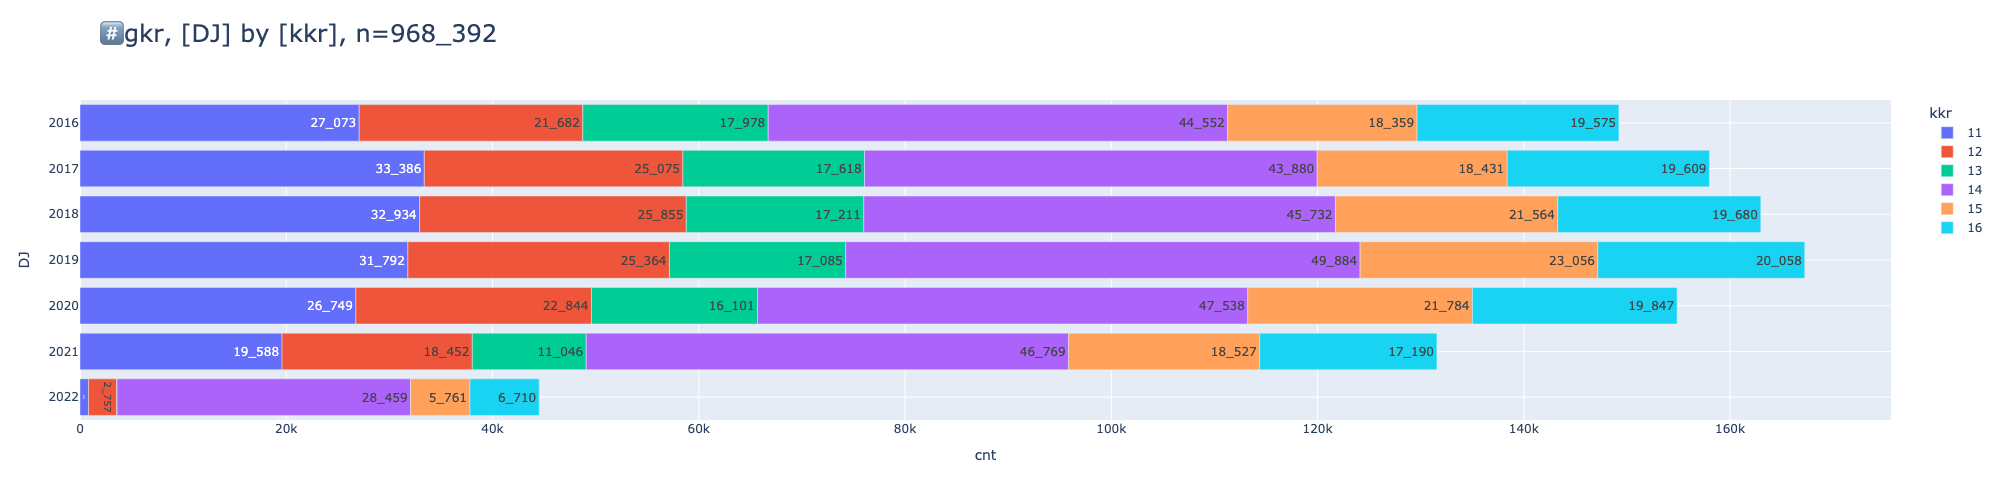

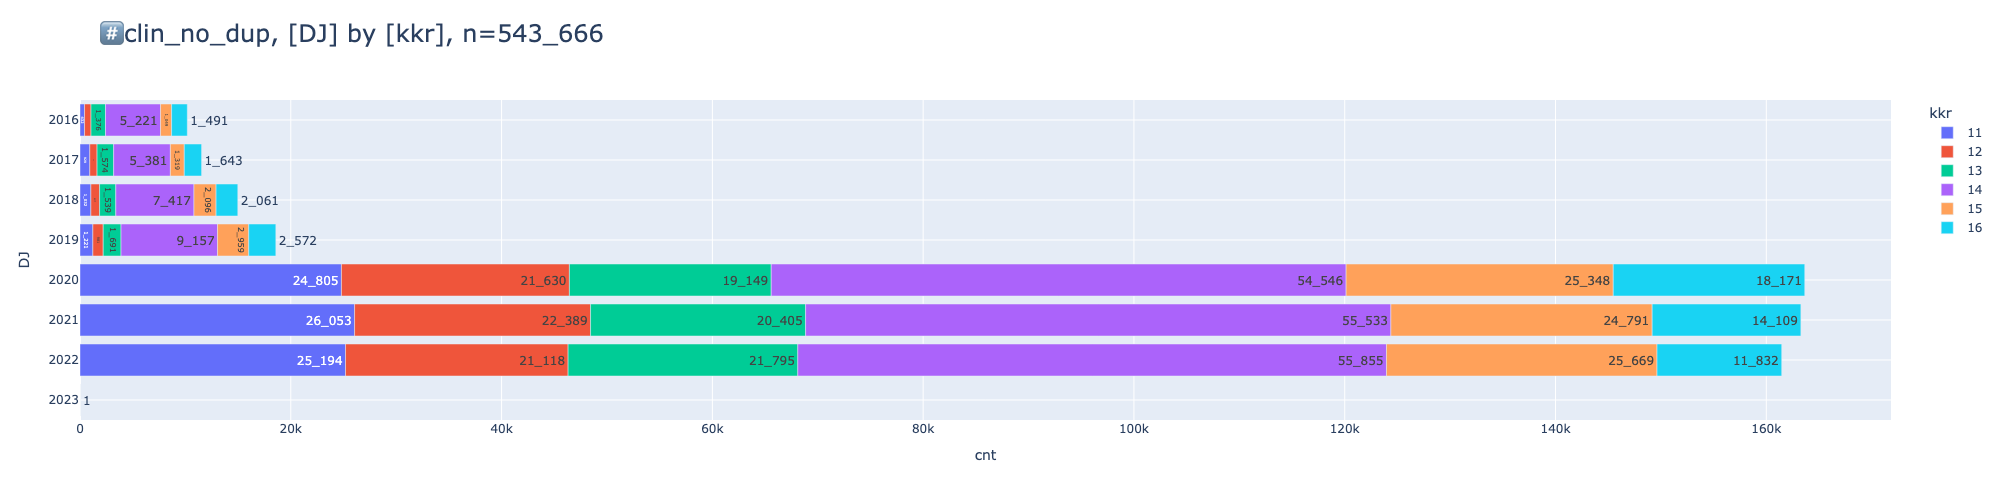

In [7]:
_df_c=db_clin_deduplicated.filter("Diagnosejahr > 2015").aggregate("cast(Lieferregister as varchar) as kkr, cast(Diagnosejahr as varchar) as DJ, count(*) as cnt").df()
# _df

_df_g=db_gkr.filter("cast(Diagnosejahr as int) > 2015").aggregate("cast(Lieferregister as varchar) as kkr, cast(Diagnosejahr as varchar) as DJ, count(*) as cnt").df()
# _df

pls.plot_stacked_bars(_df_g, swap=True, orientation='h', top_n_index=0, caption="gkr")
pls.plot_stacked_bars(_df_c, swap=True, orientation='h', top_n_index=0, caption="clin_no_dup")

## <a id='toc1_5_'></a>[Fallzahlen bei cut-off DJ 2020](#toc0_)

In [8]:
print(f"{'Anzahl Fälle GKR Archiv vor 2020:': <50}{db_gkr.filter('cast(Diagnosejahr as int) < 2020').__len__(): >10_}")
print(f"{'Anzahl Fälle GKR Länder aus klin. Daten ab 2020:': <50}{db_clin.filter('cast(Diagnosejahr as int) >= 2020').__len__(): >10_}")
print(f"{'|- nach Duplikatbereinigung:': <50}{db_clin_deduplicated.filter('cast(Diagnosejahr as int) >= 2020').__len__(): >10_}")

Anzahl Fälle GKR Archiv vor 2020:                  3_268_256
Anzahl Fälle GKR Länder aus klin. Daten ab 2020:     499_744
|- nach Duplikatbereinigung:                         488_393
